# explore results (BayLearn)

host = ```any```, device = ```cuda:1```

**Motivation**: <br>

Load from ```../tmp/results_2025-08```

In [1]:
# HIDE CODE


project_name = '_TemporalSC'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

## Results dir

In [3]:
results_dir = pjoin(tmp_dir, 'results_2025-08')
files = sorted(os.listdir(results_dir), key=alphanum_sort_key)
len(files)

69

In [4]:
files

['poisson_<ngd|lin>_Kyoto16-wht_t-16_b-0.1_kms-(32,1,1)_BayLearn_chewie-0_(2025_08_02,16:04).npy',
 'poisson_<ngd|lin>_Kyoto16-wht_t-16_b-0.1_kms-(128,1,1)_BayLearn_chewie-0_(2025_08_03,04:37).npy',
 'poisson_<ngd|lin>_Kyoto16-wht_t-16_b-0.1_kms-(768,1,1)_BayLearn_chewie-0_(2025_08_03,20:30).npy',
 'poisson_<ngd|lin>_Kyoto16-wht_t-16_b-0.1_kms-(1024,1,1)_BayLearn_chewie-0_(2025_08_02,16:04).npy',
 'poisson_<ngd|lin>_Kyoto16-wht_t-16_b-1_kms-(32,1,1)_BayLearn_chewie-0_(2025_08_02,16:04).npy',
 'poisson_<ngd|lin>_Kyoto16-wht_t-16_b-1_kms-(128,1,1)_BayLearn_chewie-0_(2025_08_03,06:03).npy',
 'poisson_<ngd|lin>_Kyoto16-wht_t-16_b-1_kms-(512,1,1)_BayLearn_chewie-0_(2025_08_02,16:04).npy',
 'poisson_<ngd|lin>_Kyoto16-wht_t-16_b-1_kms-(768,1,1)_BayLearn_chewie-0_(2025_08_03,22:21).npy',
 'poisson_<ngd|lin>_Kyoto16-wht_t-16_b-1_kms-(1024,1,1)_BayLearn_chewie-0_(2025_08_03,05:38).npy',
 'poisson_<ngd|lin>_Kyoto16-wht_t-16_b-1_kms-(2048,1,1)_BayLearn_chewie-0_(2025_08_04,20:43).npy',
 'poisson_<

In [26]:
df = collections.defaultdict(list)

for f in tqdm(files):
    # load
    load = np.load(
        pjoin(results_dir, f),
        allow_pickle=True,
    ).item()

    # info
    items = ['kl_beta', 'latent_channels']
    for item in items:
        df[item].append(load['info'][item])

    # results
    items = ['r2', '%-zeros', 'euc_dist', 'n_active']
    for item in items:
        df[item].append(load['results'][item][-1])
        
df = pd.DataFrame(df)

100%|███████████████████████████████████████████| 69/69 [00:02<00:00, 25.46it/s]


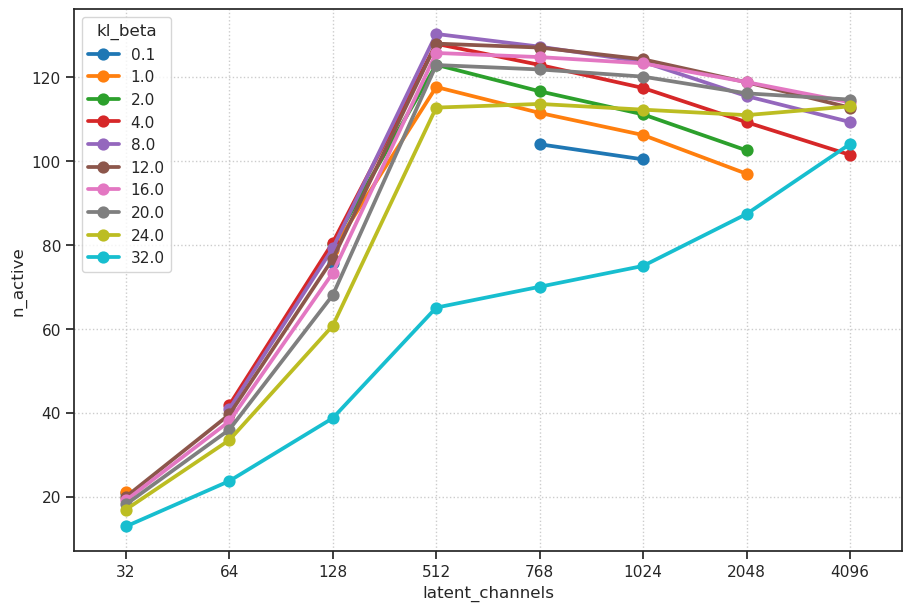

In [37]:
fig, ax = create_figure(1, 1, (9, 6))

sns.pointplot(
    data=df,
    x='latent_channels',
    y='n_active',
    hue='kl_beta',
    palette='tab10',
)
add_grid(ax)
plt.show()

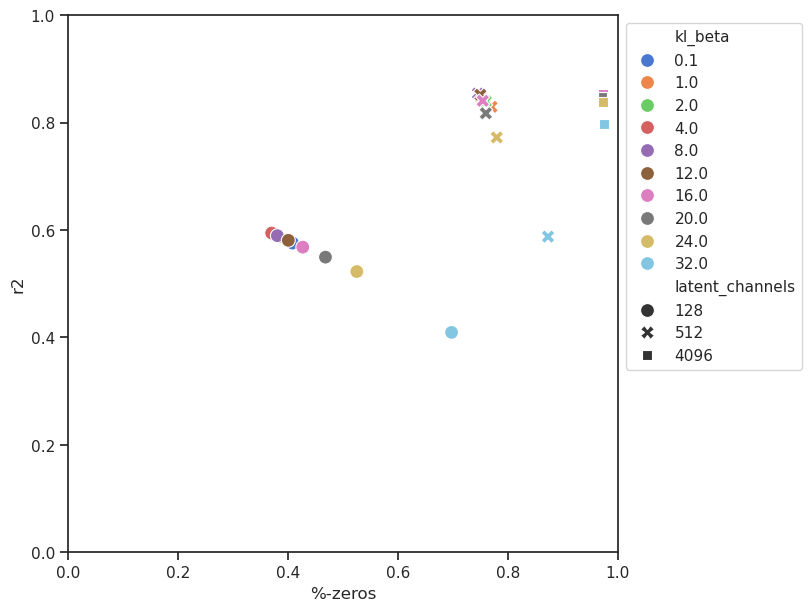

In [59]:
fig, ax = create_figure(1, 1, (8, 6))

_df = df.loc[df['latent_channels'].isin([128, 512, 4096])]

sns.scatterplot(
    data=_df,
    x='%-zeros',
    y='r2',
    style='latent_channels',
    palette='muted',
    hue='kl_beta',
    s=100,
    ax=ax,
)
ax.set(xlim=(0, 1), ylim=(0, 1))
move_legend(ax, (1, 1))
plt.show()